# andreeva2024 — Metric Space Magnitude & Generalisation

**Andreeva, Limbeck, Rieck & Sarkar (2023/24).**
*Metric space magnitude and generalisation in neural networks.*
TAG-ML 2023 (PMLR 221). — [arXiv:2305.05611](https://arxiv.org/abs/2305.05611) ·
[code (magnipy)](https://github.com/aidos-lab/magnipy)

A network's training run traces a path `W = {W_1, …, W_T}` through weight space.
This paper measures the **metric-space magnitude** of that path and shows its growth
rate — the **magnitude dimension** — tracks how well the network generalises.

## What the paper does

**Metric space magnitude** is a single number summarising the "effective size" of a
finite metric space — loosely, *how many points it looks like* at a given scale.
For a set of points with pairwise distance matrix `D` and a scale `t > 0`, form the
similarity matrix `ζ_t = exp(−t · D)` and solve `ζ_t w = 1`; the magnitude is the
sum of the weight vector,

$$\mathrm{Mag}(tX) \;=\; \sum_i w_i, \qquad \zeta_t\, w = \mathbf{1}.$$

* At **small `t`** every point looks the same → `Mag → 1` (one effective point).
* At **large `t`** points are fully resolved → `Mag → N` (the cardinality).

**Magnitude function.**  Sweeping `t` traces `t ↦ Mag(tX)`.  Its growth rate is the

**Magnitude dimension** — the slope of `log Mag(tX)` vs `log t`, an intrinsic-
dimension-like descriptor of the point set.

**Applied to learning.**  The paper computes magnitude on the network across
training and finds it is predictive of generalisation: broadly, a **lower magnitude
dimension** of the trajectory/representation goes with **better generalisation**
(Fig. 3).  This toolkit's `andreeva2024` preset computes the magnitude dimension of
the **weight trajectory** `{W_i}` captured during training.

### Expected behaviour

| Quantity | Paper finding |
|---|---|
| `log Mag(tX)` vs `log t` | roughly linear over a scale band → a well-defined slope |
| magnitude dimension ↓ | better generalisation (lower gap) — Fig. 3 |
| datasets / models | CIFAR-10 & CIFAR-100 with ResNet-18 / AlexNet / VGG |

At the toy scale below (a `SmallCNN`, ~24 trajectory points, brief training) you
should see a clean log-log magnitude-scaling line with a sensible slope; the
*generalisation correlation* itself needs a population of models (see the notes).

## Why do we hand the trajectory to the pipeline — and do we have to?

**Short answer: you don't have to.**  The pipeline core is deliberately
*data-agnostic* — `.fit()` consumes plain arrays, so the very same magnitude engine
works whether the trajectory came from PyTorch, TensorFlow, or a CSV on disk.  The
notebooks often show the explicit `view.weight_trajectory()` step purely to make the
intermediate visible.

But the pipeline *also* accepts the model objects directly.  `.fit()` / `.reproduce()`
/ `.fit_training()` detect a `TrainingView` (or `ModelSnapshot`) and call the
**model-adapter**, which pulls exactly the array the chosen tool needs — here, the
weight trajectory.  So

```python
pipe.reproduce(view)                      # model-first
pipe.reproduce(view.weight_trajectory())  # explicit — identical result
```

are equivalent (verified below).  You extract explicitly only when you want to
inspect or post-process the intermediate yourself, or when you're feeding data the
adapter can't infer.  This notebook uses the model-first form.

## Setup

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make `paper_reproduce` importable
import numpy as np
import matplotlib.pyplot as plt
import torch

from tanc import TDAPipeline
from tanc.model_extractor import TrainingExtractor
from paper_reproduce._torch_setup import load_cifar10, SmallCNN, pick_device

warnings.filterwarnings("ignore")
np.random.seed(0); torch.manual_seed(0)
DEVICE = pick_device()                      # 'cuda' → 'mps' (Apple GPU) → 'cpu'
print("training device:", DEVICE)

training device: mps


## 1. Train a small model and capture its weight trajectory

We snapshot the weights every couple of iterations so the `TrainingView` holds an
ordered path `{W_i}` through weight space — the metric space whose magnitude we
measure.

In [2]:
X_tr, y_tr = load_cifar10("train", n_samples=1500)
X_te, y_te = load_cifar10("test",  n_samples=400)
model = SmallCNN(in_channels=3, num_classes=10, width=8)

ext = TrainingExtractor(
    model=model,
    train_data=(X_tr, y_tr), batch_size=64,
    criterion=torch.nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3),
    val_data=(X_te, y_te), extract_data=X_te[:64],
    aspects=["weights"],
    snapshot_every=2, snapshot_schedule="iteration",
    device=DEVICE, clarify=False,
)
view = ext.run(epochs=2, target_accuracy=None, verbose=False)
print(f"trajectory length: {len(view)} weight snapshots")

trajectory length: 24 weight snapshots


## 2. Reproduce via `TDAPipeline.from_paper` — model-first

`reproduce(view)` hands the `TrainingView` straight to the pipeline: the model-
adapter extracts the weight trajectory, and the dimension tool computes the
magnitude function and its slope.

TDAPipeline — Andreeva et al. (2024)
  Stage 1: (skipped — direct dimension estimation)
  Stage 2: tool    = dimension
             method = 'magnitude'
             estimator = 'trajectory_dimension'
  Default plot   : .plot('magnitude_scaling')
TopoResult(tool='dimension')
  paper       : Andreeva et al. (2024)
  data        : dimension_result (method=magnitude_dimension, dim=0.860)
  plots       :
    .plot('magnitude_scaling') — Log-log Mag(tX) vs t with fitted slope.
  config keys : method


"TopoResult(tool='dimension')\n  paper       : Andreeva et al. (2024)\n  data        : dimension_result (method=magnitude_dimension, dim=0.860)\n  plots       :\n    .plot('magnitude_scaling') — Log-log Mag(tX) vs t with fitted slope.\n  config keys : method"

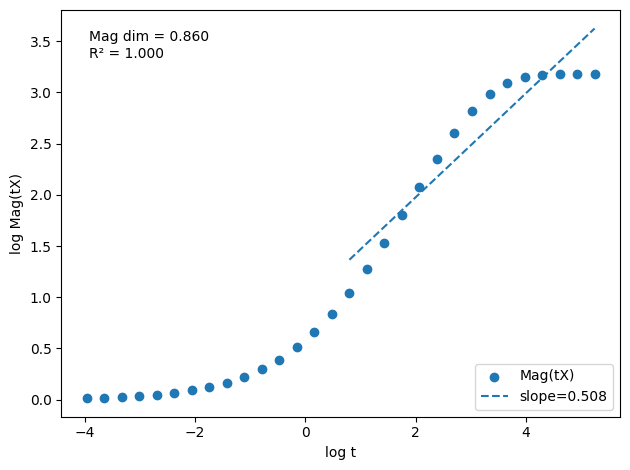

In [3]:
pipe = TDAPipeline.from_paper("andreeva2024")
pipe.explain()

result, fig = pipe.reproduce(view)          # model-first — adapter pulls the trajectory
# Equivalent explicit form:
#   result, fig = pipe.reproduce(view.weight_trajectory())
result.describe()

In [4]:
dr = result.dimension_result
print(f"magnitude dimension = {dr['magnitude_dimension']:.4f}")
print(f"log-log fit R^2     = {dr['r_squared']:.4f}   (closer to 1 = cleaner scaling)")

magnitude dimension = 0.8596
log-log fit R^2     = 0.9998   (closer to 1 = cleaner scaling)


## Notes & gaps

* **Implements the method as described**:** metric-space magnitude of a *real* weight trajectory and its
  magnitude dimension (the slope of the log–log magnitude-scaling line), via
  `TDAPipeline.from_paper("andreeva2024")`.
* **Model-first vs explicit:** `pipe.reproduce(view)` ≡
  `pipe.reproduce(view.weight_trajectory())` — the pipeline's model-adapter does the
  extraction for you; the explicit call is only for when you want the array in hand.
* **The generalisation correlation** (Fig. 3) needs a *population* of models trained
  at varying scales: compute one magnitude dimension per model and correlate it with
  each model's generalisation gap.  Use `plot_magnitude_dimension_over_training(view)`
  for the per-epoch view of a single run, and the reference `magnipy` library for the
  full multi-model sweep.

## Template — run your *own* `TDAPipeline` config on a `SmallCNN`

A drop-in template you can copy and tweak.  Edit the **`CONFIG`** block in the next
cell — model size, training budget, and which pipeline to run — then execute.
Everything downstream (build → train → analyse) is driven entirely by those dicts;
no other edits needed.

Two pipeline modes:

* **`"preset"`** — reproduce a published method via `TDAPipeline.from_paper(...)`,
  optionally overriding any parameter with dotted keys
  (e.g. `{"tool_kwargs__method": "ph_euclidean"}`).
* **`"explicit"`** — assemble your own `builder` + `tool` combination directly.

> **Aspect ↔ builder dependency:** trajectory/weight tools only need
> `aspects=["weights"]`; activation-based builders (`"activation_graph"`,
> `"polyhedral_graph"`, …) also need `"activations"`.  Set `TRAIN["aspects"]`
> accordingly or the adapter won't have the array your tool wants.

In [5]:
# ============================================================================
#  CONFIG  —  edit me, then run the cell below
# ============================================================================

# ── 1. SmallCNN architecture (paper_reproduce._torch_setup.SmallCNN) ─────────
MODEL = dict(
    in_channels = 3,    # 3 = CIFAR-10/100,  1 = MNIST / Fashion-MNIST
    num_classes = 10,
    width       = 8,    # base conv width; the 2nd conv stage uses 2×width
)

# ── 2. Training budget + what to snapshot ────────────────────────────────────
TRAIN = dict(
    n_train           = 1500,
    n_test            = 400,
    epochs            = 2,
    batch_size        = 64,
    lr                = 1e-3,
    snapshot_every    = 2,             # capture every N steps of the schedule
    snapshot_schedule = "iteration",   # "iteration" | "epoch"
    aspects           = ["weights"],   # add "activations" for activation builders
)

# ── 3. Which pipeline to run ─────────────────────────────────────────────────
PIPELINE = dict(
    mode = "preset",                   # "preset"  or  "explicit"

    # --- mode == "preset" ---
    preset    = "andreeva2024",        # any key from TDAPipeline.from_paper
    overrides = {},                    # dotted overrides, e.g.
                                       #   {"tool_kwargs__method": "ph_euclidean"}

    # --- mode == "explicit" --- (ignored unless mode == "explicit")
    builder        = "weight_trajectory",   # or "activation_graph", "weight_graph", None, …
    builder_kwargs = {"distance": "euclidean"},
    tool           = "dimension",           # "ph" | "mapper" | "dimension"
    tool_kwargs    = {"method": "magnitude", "estimator": "trajectory_dimension"},
    visualisation  = "magnitude_scaling",
)


trajectory length: 24 snapshots
TDAPipeline — Andreeva et al. (2024)
  Stage 1: (skipped — direct dimension estimation)
  Stage 2: tool    = dimension
             method = 'magnitude'
             estimator = 'trajectory_dimension'
  Default plot   : .plot('magnitude_scaling')
TopoResult(tool='dimension')
  paper       : Andreeva et al. (2024)
  data        : dimension_result (method=magnitude_dimension, dim=0.860)
  plots       :
    .plot('magnitude_scaling') — Log-log Mag(tX) vs t with fitted slope.
  config keys : method


"TopoResult(tool='dimension')\n  paper       : Andreeva et al. (2024)\n  data        : dimension_result (method=magnitude_dimension, dim=0.860)\n  plots       :\n    .plot('magnitude_scaling') — Log-log Mag(tX) vs t with fitted slope.\n  config keys : method"

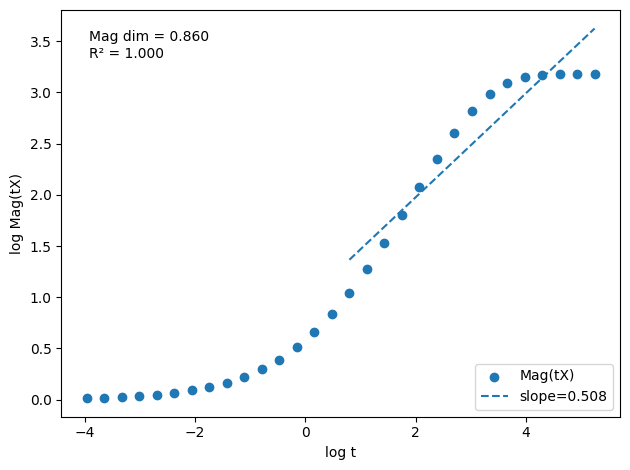

In [6]:
# ── Build & train the SmallCNN from CONFIG ──────────────────────────────────
np.random.seed(0); torch.manual_seed(0)

# dataset picked from in_channels: 1 → MNIST, 3 → CIFAR-10
if MODEL["in_channels"] == 1:
    from paper_reproduce._torch_setup import load_mnist
    X_tr, y_tr = load_mnist("train", n_samples=TRAIN["n_train"], flatten=False)
    X_te, y_te = load_mnist("test",  n_samples=TRAIN["n_test"],  flatten=False)
else:
    X_tr, y_tr = load_cifar10("train", n_samples=TRAIN["n_train"])
    X_te, y_te = load_cifar10("test",  n_samples=TRAIN["n_test"])

my_model = SmallCNN(**MODEL)

ext = TrainingExtractor(
    model=my_model,
    train_data=(X_tr, y_tr), batch_size=TRAIN["batch_size"],
    criterion=torch.nn.CrossEntropyLoss(),
    optimizer=torch.optim.Adam(my_model.parameters(), lr=TRAIN["lr"]),
    val_data=(X_te, y_te), extract_data=X_te[:64],
    aspects=TRAIN["aspects"],
    snapshot_every=TRAIN["snapshot_every"],
    snapshot_schedule=TRAIN["snapshot_schedule"],
    device=DEVICE, clarify=False,
)
my_view = ext.run(epochs=TRAIN["epochs"], target_accuracy=None, verbose=False)
print(f"trajectory length: {len(my_view)} snapshots")

# ── Build the pipeline (preset or explicit) ─────────────────────────────────
if PIPELINE["mode"] == "preset":
    my_pipe = TDAPipeline.from_paper(PIPELINE["preset"], **PIPELINE["overrides"])
else:
    my_pipe = TDAPipeline(
        builder=PIPELINE["builder"],
        builder_kwargs=PIPELINE["builder_kwargs"],
        tool=PIPELINE["tool"],
        tool_kwargs=PIPELINE["tool_kwargs"],
        visualisation=PIPELINE["visualisation"],
    )
my_pipe.explain()

# ── Run it: the model-adapter pulls whatever array the tool needs ───────────
my_result, my_fig = my_pipe.reproduce(my_view)
my_result.describe()

## Deviations from the paper

Everything this notebook does differently from the source, and why. An empty
table below means the construction follows the paper as written — that is a
claim, not an omission. Scale always differs; see the last row.

| aspect | the paper | this notebook | why it matters |
|---|---|---|---|
| sample size | large point clouds | a few hundred trajectory points | magnitude dimension converges slowly in d, so the estimate is biased low |
| scale | the paper's full experimental setup | a smaller model, fewer samples, fewer epochs | to keep the notebook runnable in minutes; expect weaker effects than published |
